# Graphical Method

Two special cases of zero-sum matrix games can be handled using a visual display:

- $n \times 2$
- $2\times n$

We will employ the <span style='color:blue'><b>graphical method</span></b> to solve these two cases.

In [43]:
## Do not change this cell, only execute it. 
## This cell initializes Python so that pandas, numpy and scipy packages are ready to use.

import datascience
%matplotlib inline
import matplotlib.pyplot as plots
plots.style.use('fivethirtyeight')
import numpy as np
import math
import scipy.stats as stats
from fractions import Fraction

## Code for Finding the Point of Intersection

The following code will instruct Python to create lines in slope-intercept form and find the point where they intersect. This allows us to solve graphically for the equilibrium point $(x_0, y_0)$ where

- $x_0$ is the <span style='color:blue'><b>optimal proportion</b></span> of times A should be played by the player with 2 strategies.
- $y_0$ is the <span style='color:blue'><b>game value</b></span>.

### get_slope_int() Function

The code for the function **get_slope_int()** is shown below:

In [44]:
def get_slope_int(p1, p2):
    m = (p2[1] - p1[1]) / (p2[0] - p1[0])
    b = p1[1] - m * p1[0]
    return m, b

### Doing the Algebra
The calculations based upon the two lines that intersect follow. Notice that we use the **Fraction()** function to rationalize the point of intersection. The values in game theory are rarely irrational, so having the fractional form of the value helps ensure our algebraic computations are correct.

In [45]:
m1, b1 = get_slope_int(points1[0], points1[1])
m2, b2 = get_slope_int(points3[0], points3[1])
x_0 = (b2 - b1) / (m1 - m2)
y_0 = m1 * x_0 + b1

# Rationalize the values
rx = Fraction(x_0).limit_denominator()
ry = Fraction(y_0).limit_denominator()
#plots.scatter(x_0, y_0, color='yellow', label=f'Intersection ({rx}, {ry})', zorder=3)

Above, we commented the final line of code as, being a plot command, it tries to plot the point of intersection. With no grid, no coordinate axes, and no other lines, this plot is useless. It will work well when combined with other graphical elements.

## Example 1

$$\begin{array}{cc}&\textbf{Colin}\\\textbf{Rose}& \begin{array}{r|ccc} & A & B & C\\\hline A & 1 & 3 & 5 \\ B & 6 & 2 & 1\end{array} \end{array}$$

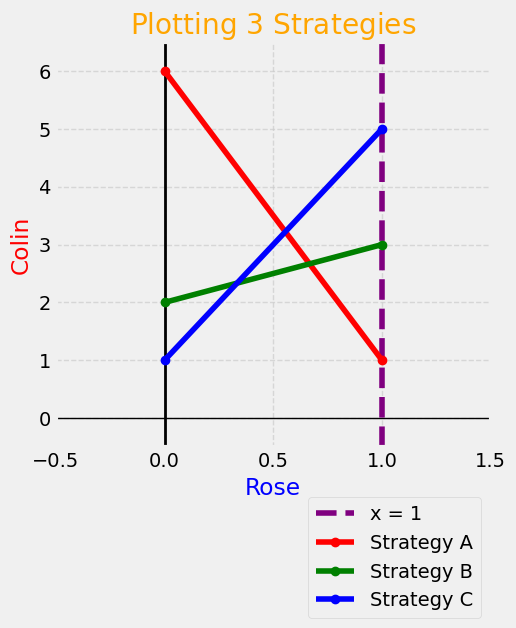

In [46]:
plots.figure(figsize=(5,5))
plots.axhline(0, color='black', linewidth=1)
plots.axvline(0, color='black', linewidth=2)
plots.xlim(-0.5, 1.5); plots.ylim(-0.5, 6.5)
plots.axvline(x=1, color='purple', linestyle='--', label='x = 1')

points1 = ((0, 6), (1, 1))
plots.plot(*zip(*points1), marker='o', color='red', label='Strategy A')

points2 = ((0, 2), (1, 3))
plots.plot(*zip(*points2), marker='o', color='green', label='Strategy B')

points3 = ((0, 1), (1, 5))
plots.plot(*zip(*points3), marker='o', color='blue', label='Strategy C')

# Add labels and title
plots.xlabel('Rose', color='blue')
plots.ylabel('Colin', color='red')
plots.title('Plotting $3$ Strategies', color='orange')

# Add a grid, add legend, and place legend below figure.
plots.grid(True, linestyle='--', alpha=0.7)
plots.legend(loc='upper right', bbox_to_anchor=(1, -0.1),framealpha=0.75)
plots.show()

We can see above that, for Colin, Strategy **B** (in green) is not active. Thus, we wish to find the intersection of the lines representing strategies **A** and **C**.

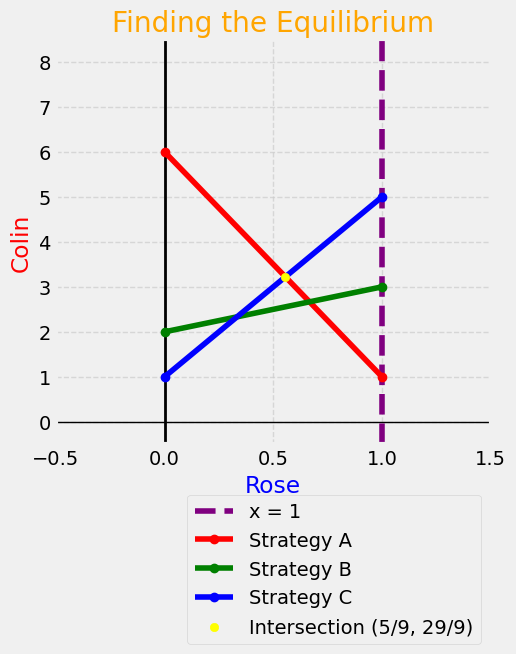

In [47]:
plots.figure(figsize=(5,5))
plots.axhline(0, color='black', linewidth=1)
plots.axvline(0, color='black', linewidth=2)
plots.xlim(-0.5, 1.5); plots.ylim(-0.5, 8.5)
plots.axvline(x=1, color='purple', linestyle='--', label='x = 1')

points1 = ((0, 6), (1, 1))
plots.plot(*zip(*points1), marker='o', color='red', label='Strategy A')

points2 = ((0, 2), (1, 3))
plots.plot(*zip(*points2), marker='o', color='green', label='Strategy B')

points3 = ((0, 1), (1, 5))
plots.plot(*zip(*points3), marker='o', color='blue', label='Strategy C')

m1, b1 = get_slope_int(points1[0], points1[1])
m2, b2 = get_slope_int(points3[0], points3[1])
x_0 = (b2 - b1) / (m1 - m2)
y_0 = m1 * x_0 + b1

# Rationalize the values
rx = Fraction(x_0).limit_denominator()
ry = Fraction(y_0).limit_denominator()
plots.scatter(x_0, y_0, color='yellow', label=f'Intersection ({rx}, {ry})', zorder=3)

# Add labels and title
plots.xlabel('Rose', color='blue')
plots.ylabel('Colin', color='red')
plots.title('Finding the Equilibrium', color='orange')

# Add a grid, add legend, and place legend below figure.
plots.grid(True, linestyle='--', alpha=0.7)
plots.legend(loc='upper right', bbox_to_anchor=(1, -0.1),framealpha=0.75)
plots.show()

## Solution

The two strategies that will be active for Colin are **A** and **C**. We can thus solve the game by solving the $2\times 2$ subgame below:

$$\begin{array}{cc}&\textbf{Colin}\\\textbf{Rose}& \begin{array}{r|cc} & A & C\\\hline A & 1 & 5 \\ B & 6 & 1 \end{array} \end{array}$$

The row oddments are $4$ and $5$, so Rose will play $\vec r = \left[\begin{array}{c}5/9\\4/9\end{array}\right]$. The column oddments are $5$ and $4$, Colin will play $\vec c = \left[\begin{array}{c}4/9\\0\\5/9\end{array}\right]$. Knowing the optimal strategy sets for Rose and Colin, we can quickly verify the value of the game:
$$v=\frac{29}{9}$$

## Example 2

$$\begin{array}{cc}&\textbf{Colin}\\\textbf{Rose}& \begin{array}{r|ccc} & A & B & C\\\hline A & 1 & 3 & 11 \\ B & 8 & 5 & 2 \end{array} \end{array}$$

## Example 3

$$\begin{array}{cc}&\textbf{Colin}\\\textbf{Rose}& \begin{array}{r|cc} & A & B\\\hline A & 2 & 4 \\ B & 3 & 1 \\ C & 5 & 0 \end{array} \end{array}$$